In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

## 데이터 확인

In [3]:
df = pd.read_csv('./data/hotel_data_modified.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,A,0,394.0,NaN,0,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,E,0,9.0,NaN,0,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,D,0,9.0,NaN,0,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,A,0,89.0,NaN,0,0,0,Check-Out,2017-09-07


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,8.000000,5.000000


#### 전체 상관행렬

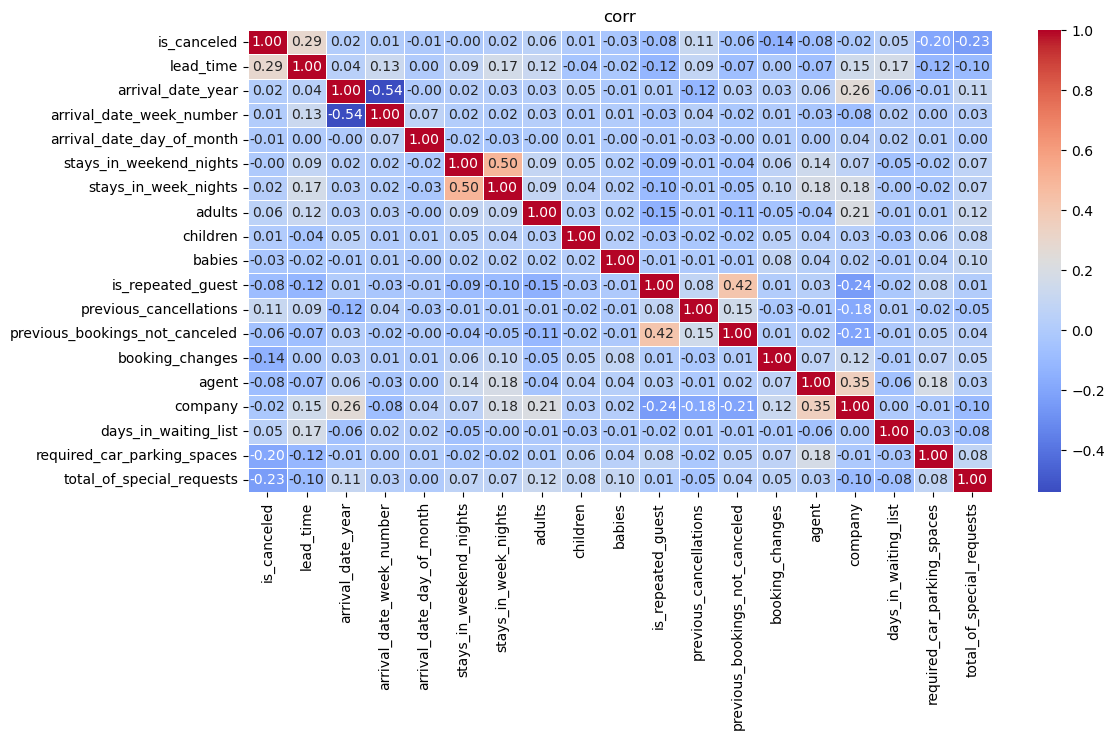

In [8]:
# 히트맵 시각화
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("corr")
plt.show()

## 결측값 처리

In [10]:
df1 = df.copy()

In [11]:
df1.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
agent                              16340
company                           112593
days_in_waiting_

In [12]:
missing_ratio = (df1.isnull().sum() / len(df1)) * 100

In [13]:
# 결측값 4개 : 결측값 0으로 대체 (아이를 동반하지 않는 예약으로 간주)
df1['children'] = df1['children'].fillna(0)
df1['children'].isnull().sum()

0

In [14]:
df1['country'] = df1['country'].fillna('Unknown')
df1['country'].isnull().sum()

0

In [15]:
# 나머지 결측값이 있는 컬럼 삭제
df1.drop(columns = df1[['agent','company']],inplace=True)

## 중복값 처리

In [17]:
# 월(month): '문자열 -> 숫자' 변환
df1['arrival_date_month'] = pd.to_datetime(df1['arrival_date_month'], format="%B").dt.month

In [18]:
df1['arrival_date'] = pd.to_datetime(
    df1['arrival_date_year'].astype(str) + "-" +
    df1['arrival_date_month'].astype(str) + "-" +
    df1['arrival_date_day_of_month'].astype(str),
    format =  "%Y-%m-%d"
)
df1['arrival_date']

0        2015-07-01
1        2015-07-01
2        2015-07-01
3        2015-07-01
4        2015-07-01
            ...    
119385   2017-08-30
119386   2017-08-31
119387   2017-08-31
119388   2017-08-31
119389   2017-08-29
Name: arrival_date, Length: 119390, dtype: datetime64[ns]

In [19]:
# colums 삭제
df1.drop(columns = ['arrival_date_year','arrival_date_month','arrival_date_day_of_month','arrival_date_week_number'],inplace=True)

In [20]:
df1

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,C,C,3,0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,C,C,4,0,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,0,A,C,0,0,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,0,13,0,1,1,0.0,0,BB,GBR,...,0,A,A,0,0,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,A,A,0,0,0,1,Check-Out,2015-07-03,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2,5,2,0.0,0,BB,BEL,...,0,A,A,0,0,0,0,Check-Out,2017-09-06,2017-08-30
119386,City Hotel,0,102,2,5,3,0.0,0,BB,FRA,...,0,E,E,0,0,0,2,Check-Out,2017-09-07,2017-08-31
119387,City Hotel,0,34,2,5,2,0.0,0,BB,DEU,...,0,D,D,0,0,0,4,Check-Out,2017-09-07,2017-08-31
119388,City Hotel,0,109,2,5,2,0.0,0,BB,GBR,...,0,A,A,0,0,0,0,Check-Out,2017-09-07,2017-08-31


In [21]:
df1.duplicated().sum()

33167

In [22]:
df1 = df1.drop_duplicates()
df1

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,C,C,3,0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,C,C,4,0,0,0,Check-Out,2015-07-01,2015-07-01
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,0,A,C,0,0,0,0,Check-Out,2015-07-02,2015-07-01
3,Resort Hotel,0,13,0,1,1,0.0,0,BB,GBR,...,0,A,A,0,0,0,0,Check-Out,2015-07-02,2015-07-01
4,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,A,A,0,0,0,1,Check-Out,2015-07-03,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2,5,2,0.0,0,BB,BEL,...,0,A,A,0,0,0,0,Check-Out,2017-09-06,2017-08-30
119386,City Hotel,0,102,2,5,3,0.0,0,BB,FRA,...,0,E,E,0,0,0,2,Check-Out,2017-09-07,2017-08-31
119387,City Hotel,0,34,2,5,2,0.0,0,BB,DEU,...,0,D,D,0,0,0,4,Check-Out,2017-09-07,2017-08-31
119388,City Hotel,0,109,2,5,2,0.0,0,BB,GBR,...,0,A,A,0,0,0,0,Check-Out,2017-09-07,2017-08-31


## 이상치 처리

#### 이상치 여부 확인하기

In [25]:
def detect_outliers(df, column, method="IQR", threshold=1.5):
   
    data = df[column]

    if method == "IQR":
        q1 = data.quantile(0.25)  # 1사분위수
        q3 = data.quantile(0.75)  # 3사분위수
        IQR = q3 - q1
        lower_bound = q1 - (threshold * IQR)
        upper_bound = q3 + (threshold * IQR)
        outliers = df[(data < lower_bound) | (data > upper_bound)]
    
    elif method == "Z-score":
        mean = data.mean()
        std = data.std()
        z_scores = (data - mean) / std
        outliers = df[(np.abs(z_scores) > threshold)]
    
    else:
        raise ValueError("method는 'IQR' 또는 'Z-score' 중 하나여야 합니다.")

    return outliers

In [26]:
def plot_hist_qq(data, column):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 히스토그램
    sns.histplot(data[column], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {column}")

    # Q-Q 플롯
    stats.probplot(data[column], dist="norm", plot=axes[1])
    axes[1].set_title(f"Q-Q Plot of {column}")

    plt.tight_layout()
    plt.show()

#### lead_time 이상치

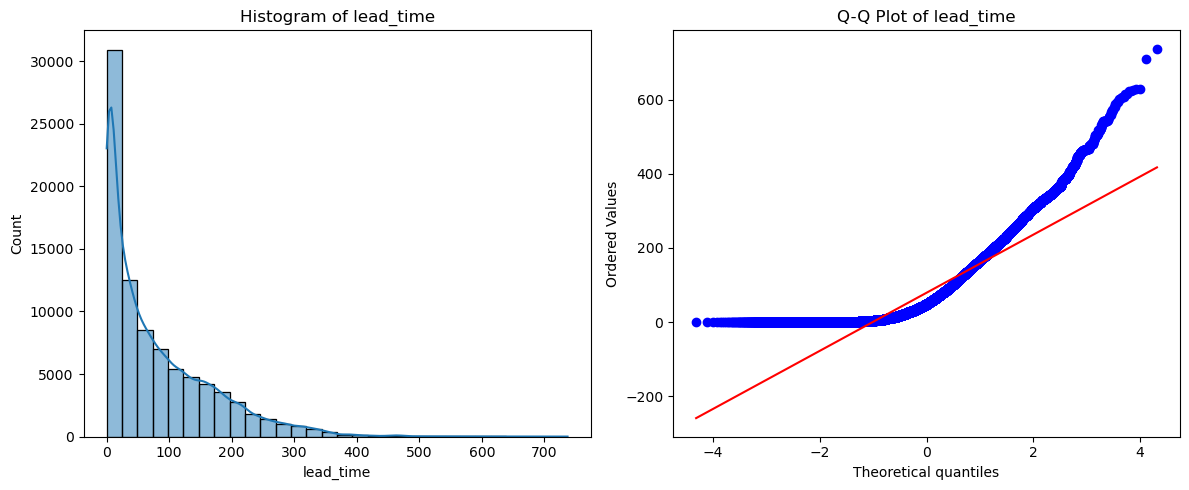

In [28]:
# lead_time 시각화
plot_hist_qq(df1,'lead_time')

- (히스토그램) : 왼쪽으로 치우친 비대칭적 분포(Positive Skewness)
- (Q-Q Plot) : 정규성을 크게 벗어남 특히, 큰 값에서 극단적인 이상치 존재

In [30]:
outlier_lead_time = detect_outliers(df1, "lead_time", method="IQR")
outlier_lead_time

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,C,C,3,0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,C,C,4,0,0,0,Check-Out,2015-07-01,2015-07-01
81,Resort Hotel,1,368,3,7,2,0.0,0,BB,PRT,...,0,A,A,0,0,0,0,Canceled,2015-05-19,2015-07-03
82,Resort Hotel,0,364,3,7,2,0.0,0,BB,GBR,...,0,A,A,0,0,0,0,Check-Out,2015-07-13,2015-07-03
85,Resort Hotel,0,324,4,10,2,0.0,0,HB,GBR,...,0,E,E,0,0,0,0,Check-Out,2015-07-17,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119148,City Hotel,0,457,2,3,2,0.0,0,HB,DEU,...,0,A,A,2,0,0,1,Check-Out,2017-08-30,2017-08-25
119228,City Hotel,0,341,2,3,2,1.0,0,BB,GBR,...,0,D,D,0,0,0,1,Check-Out,2017-09-01,2017-08-27
119296,City Hotel,0,303,0,4,1,0.0,0,BB,JPN,...,0,A,A,0,0,0,2,Check-Out,2017-09-02,2017-08-29
119297,City Hotel,0,332,0,2,2,0.0,0,BB,GBR,...,0,D,F,4,0,0,2,Check-Out,2017-09-02,2017-08-31


In [31]:
df1["lead_time"].describe()

count    86223.000000
mean        79.235680
std         85.443053
min          0.000000
25%         11.000000
50%         49.000000
75%        124.000000
max        737.000000
Name: lead_time, dtype: float64

max = 737 : mean = 104와 비교했을 때 비이상적으로 값이 크다.

하지만 'lead_time'은 예약 취소율과 비교적 상관관계가 높으므로 무조건 제거하면 안된다.

해결책) 상한선 정하기

In [34]:
# "lead_time" 컬럼에서 365 초과이면, 365 / 아니면, 원래값 그대로
df1["lead_time"] = np.where(df1["lead_time"] > 365, 365, df1["lead_time"])

/var/folders/g6/368p423d117c1pt_9pkjmw4w0000gn/T/ipykernel_87364/4093621123.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["lead_time"] = np.where(df1["lead_time"] > 365, 365, df1["lead_time"])


[ np.where() ]
- 조건에 만족하는 위치 인덱스 찾기
- 'np.where(배열에 대한 조건문, 참일 때 값, 거짓일 때 값) 형태
- array(배열)로 반환

In [36]:
df1["lead_time"].describe()

count    86223.000000
mean        78.803602
std         83.673408
min          0.000000
25%         11.000000
50%         49.000000
75%        124.000000
max        365.000000
Name: lead_time, dtype: float64

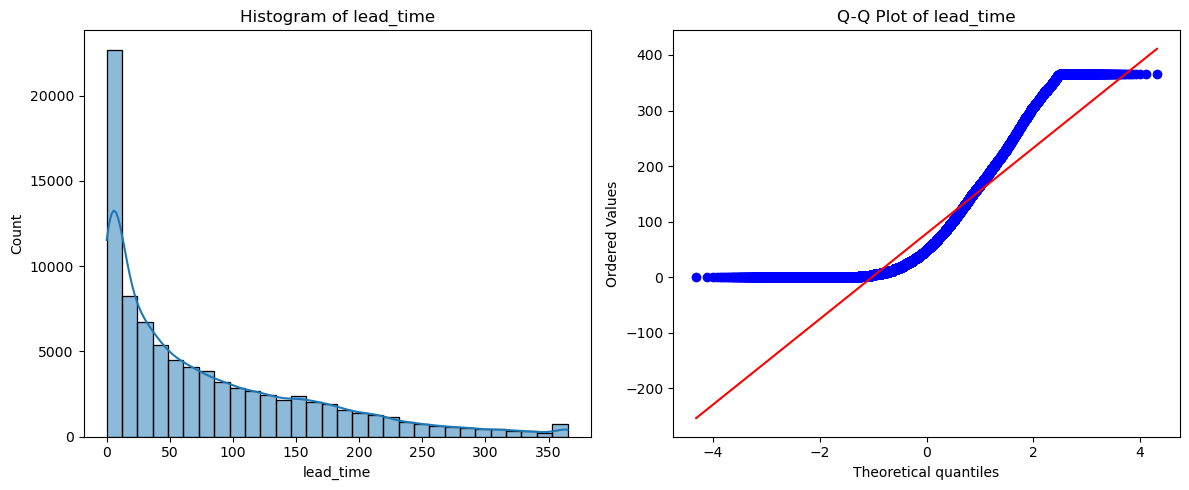

In [37]:
plot_hist_qq(df1,'lead_time')

#### previous_bookings_not_canceled 이상치

In [39]:
outlier_lead_time = detect_outliers(df1, "previous_bookings_not_canceled", method="IQR")
outlier_lead_time

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
13803,Resort Hotel,0,7,0,2,1,0.0,0,BB,Unknown,...,1,A,D,0,0,0,0,Check-Out,2016-01-15,2016-01-13
13804,Resort Hotel,0,7,1,3,1,0.0,0,BB,Unknown,...,2,A,A,0,0,1,0,Check-Out,2016-01-22,2016-01-18
13805,Resort Hotel,1,2,0,2,1,0.0,0,BB,Unknown,...,3,A,A,0,0,0,0,Canceled,2016-10-10,2016-10-12
13808,Resort Hotel,0,6,0,2,1,0.0,0,BB,PRT,...,1,A,D,1,0,0,0,Check-Out,2016-01-28,2016-01-26
13811,Resort Hotel,1,71,3,8,2,0.0,0,HB,Unknown,...,1,E,E,1,0,0,1,Canceled,2016-07-12,2016-07-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117424,City Hotel,0,3,0,1,2,1.0,0,BB,PRT,...,1,A,A,0,0,0,4,Check-Out,2017-09-01,2017-08-31
117841,City Hotel,0,7,0,2,1,0.0,0,BB,PRT,...,1,A,A,0,0,0,2,Check-Out,2017-09-01,2017-08-30
118581,City Hotel,0,11,0,2,2,0.0,0,BB,FRA,...,1,D,D,1,0,0,0,Check-Out,2017-08-27,2017-08-25
118651,City Hotel,0,189,2,0,2,0.0,0,BB,ITA,...,1,A,A,1,0,0,3,Check-Out,2017-08-29,2017-08-27


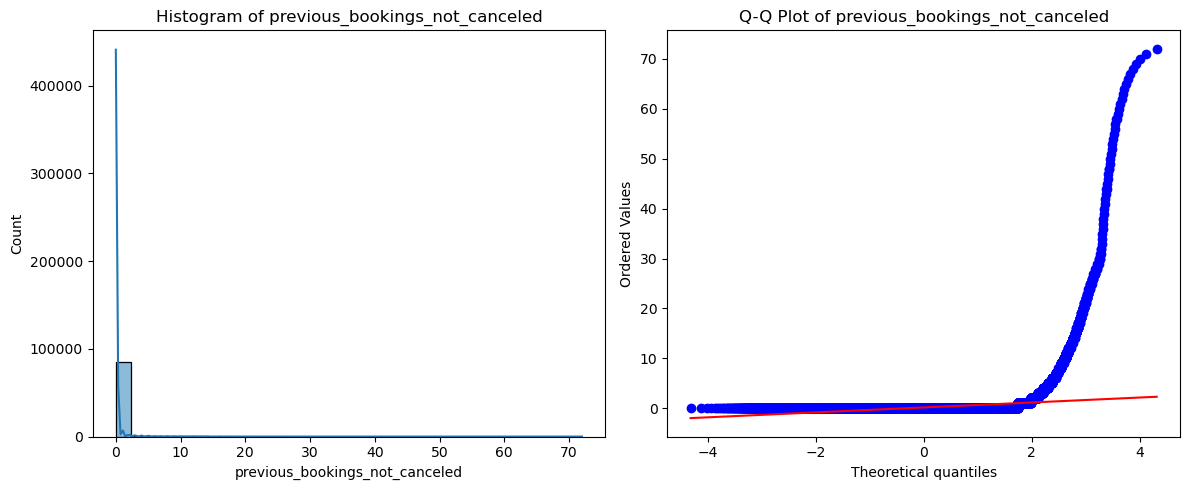

In [40]:
plot_hist_qq(df1,'previous_bookings_not_canceled')

In [41]:
df1['previous_bookings_not_canceled'].describe()

count    86223.000000
mean         0.186238
std          1.743428
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         72.000000
Name: previous_bookings_not_canceled, dtype: float64

- (히스토그램) : 범위 0~5 사이에 있음
- (Q-Q Plot) : 정규성을 따르지 않고 이상치가 존재한다

In [43]:
(df1["previous_bookings_not_canceled"]>50).sum()

23

In [44]:
df1["previous_bookings_not_canceled"] = np.where(df1["previous_bookings_not_canceled"] > 50, 50, df1["previous_bookings_not_canceled"])

/var/folders/g6/368p423d117c1pt_9pkjmw4w0000gn/T/ipykernel_87364/1901700129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["previous_bookings_not_canceled"] = np.where(df1["previous_bookings_not_canceled"] > 50, 50, df1["previous_bookings_not_canceled"])


In [45]:
df1['previous_bookings_not_canceled'].describe()

count    86223.000000
mean         0.183211
std          1.641096
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         50.000000
Name: previous_bookings_not_canceled, dtype: float64

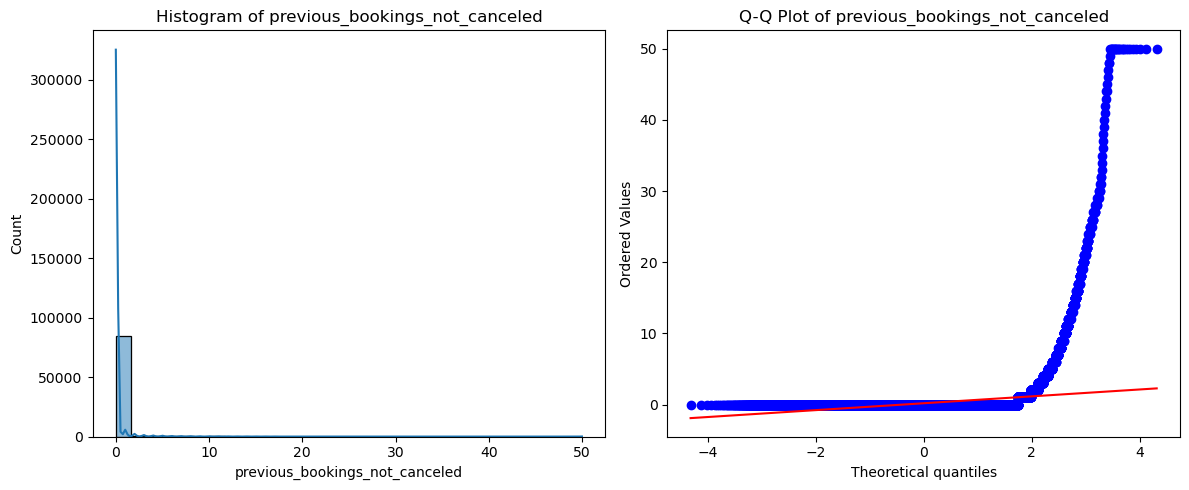

In [46]:
plot_hist_qq(df1,'previous_bookings_not_canceled')

#### previous_cancellations 이상치

In [48]:
outlier_lead_time = detect_outliers(df1, "previous_cancellations", method="IQR")
outlier_lead_time

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
13805,Resort Hotel,1,2,0,2,1,0.0,0,BB,Unknown,...,3,A,A,0,0,0,0,Canceled,2016-10-10,2016-10-12
13811,Resort Hotel,1,71,3,8,2,0.0,0,HB,Unknown,...,1,E,E,1,0,0,1,Canceled,2016-07-12,2016-07-14
13825,Resort Hotel,0,6,1,0,1,0.0,0,BB,PRT,...,1,A,A,0,0,0,0,Check-Out,2016-03-22,2016-03-21
13826,Resort Hotel,0,7,0,1,1,0.0,0,BB,PRT,...,2,A,A,0,0,0,0,Check-Out,2016-06-22,2016-06-21
13827,Resort Hotel,0,8,0,2,2,0.0,0,BB,PRT,...,3,A,A,0,0,0,0,Check-Out,2016-09-29,2016-09-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111356,City Hotel,0,10,0,1,1,0.0,0,BB,PRT,...,4,A,A,0,0,0,0,Check-Out,2017-06-23,2017-06-22
111357,City Hotel,0,20,0,3,1,0.0,0,BB,PRT,...,5,A,A,0,0,0,0,Check-Out,2017-07-14,2017-07-11
111358,City Hotel,0,8,0,1,1,0.0,0,BB,PRT,...,6,A,A,0,0,1,0,Check-Out,2017-07-26,2017-07-25
111359,City Hotel,0,13,0,1,1,0.0,0,BB,PRT,...,7,A,A,0,0,0,0,Check-Out,2017-08-30,2017-08-29


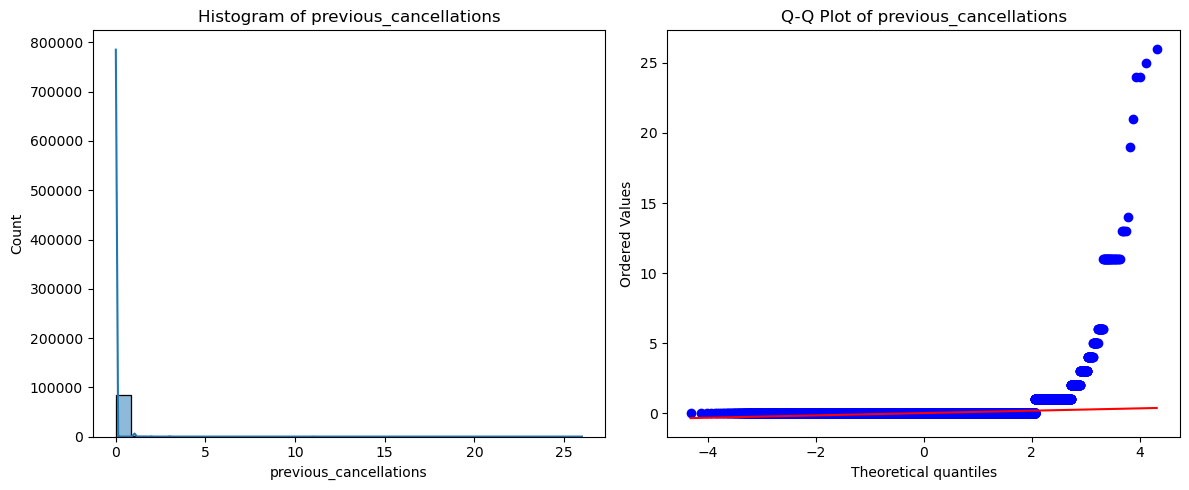

In [49]:
plot_hist_qq(df1,'previous_cancellations')

In [50]:
df1['previous_cancellations'].describe()

count    86223.000000
mean         0.030328
std          0.361404
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         26.000000
Name: previous_cancellations, dtype: float64

In [51]:
(df1["previous_cancellations"]>10).sum()

38

In [52]:
df1["previous_cancellations"] = np.where(df1["previous_cancellations"] > 10, 10, df1["previous_cancellations"])

/var/folders/g6/368p423d117c1pt_9pkjmw4w0000gn/T/ipykernel_87364/2508405284.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["previous_cancellations"] = np.where(df1["previous_cancellations"] > 10, 10, df1["previous_cancellations"])


In [53]:
df1['previous_cancellations'].describe()

count    86223.000000
mean         0.028913
std          0.298351
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: previous_cancellations, dtype: float64

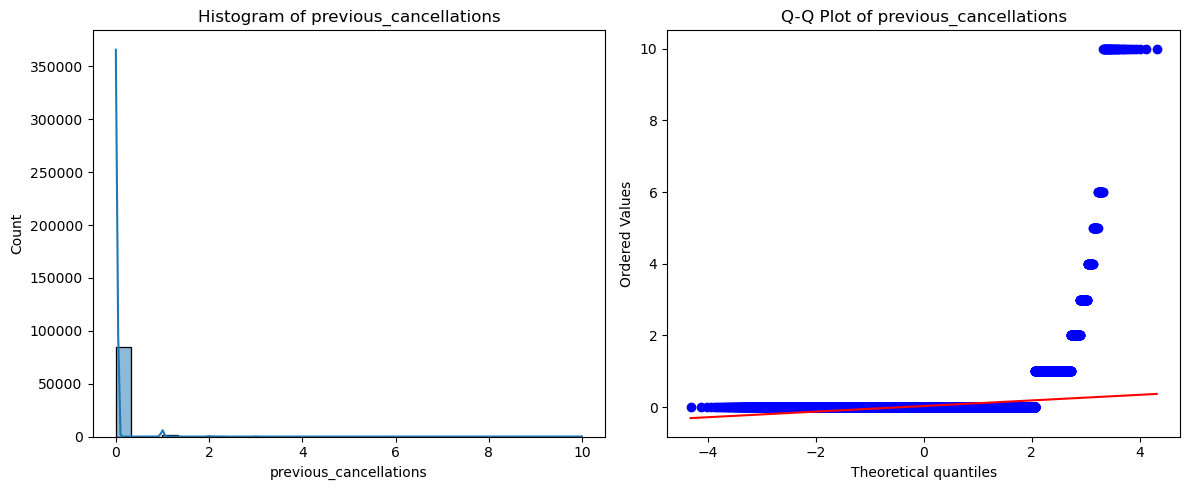

In [54]:
plot_hist_qq(df1,'previous_cancellations')

#### booking_changes 이상치

In [56]:
outlier_lead_time = detect_outliers(df1, "booking_changes", method="IQR")
outlier_lead_time

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,C,C,3,0,0,0,Check-Out,2015-07-01,2015-07-01
1,Resort Hotel,0,365,0,0,2,0.0,0,BB,PRT,...,0,C,C,4,0,0,0,Check-Out,2015-07-01,2015-07-01
13,Resort Hotel,0,18,0,4,2,1.0,0,HB,ESP,...,0,G,G,1,0,0,1,Check-Out,2015-07-05,2015-07-01
21,Resort Hotel,0,72,2,4,2,0.0,0,BB,PRT,...,0,A,A,1,0,0,1,Check-Out,2015-07-07,2015-07-01
23,Resort Hotel,0,72,2,4,2,0.0,0,BB,PRT,...,0,D,D,1,0,0,1,Check-Out,2015-07-07,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119355,City Hotel,0,111,1,5,1,0.0,0,BB,JPN,...,0,D,D,1,0,0,2,Check-Out,2017-09-04,2017-08-29
119356,City Hotel,0,111,1,5,2,0.0,0,BB,DEU,...,0,D,D,3,0,0,1,Check-Out,2017-09-04,2017-08-29
119359,City Hotel,0,63,1,3,2,0.0,0,SC,BRA,...,0,A,A,1,0,0,1,Check-Out,2017-09-04,2017-08-31
119362,City Hotel,0,198,1,5,2,0.0,0,BB,ITA,...,0,A,A,2,0,0,2,Check-Out,2017-09-04,2017-08-29


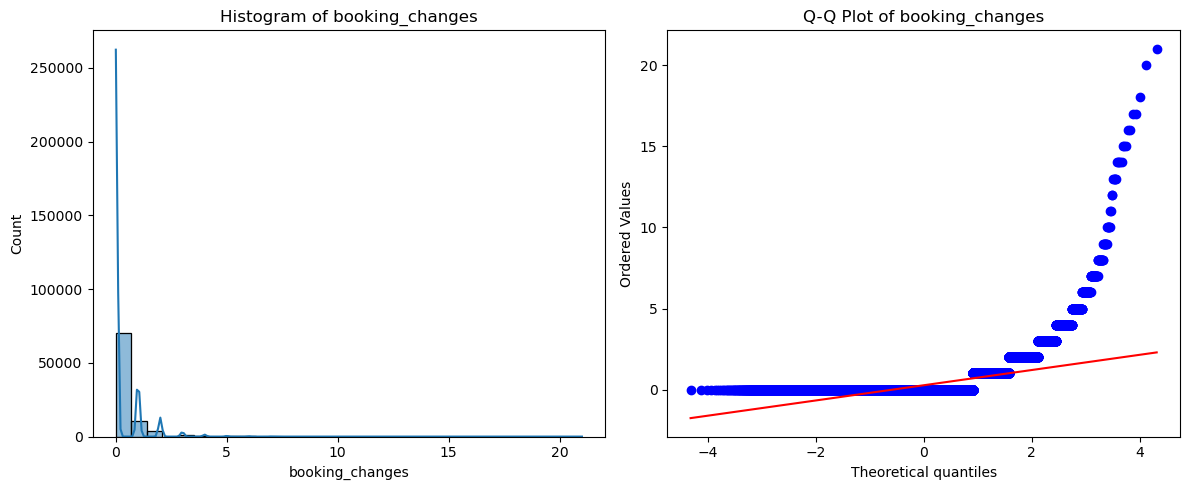

In [57]:
plot_hist_qq(df1,'booking_changes')

In [58]:
df1['booking_changes'].describe()

count    86223.000000
mean         0.271702
std          0.729222
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: booking_changes, dtype: float64

In [59]:
(df1["booking_changes"] > 10).sum()

24

In [60]:
(df1["booking_changes"] > 15).sum()

7

In [61]:
df1["booking_changes"] = np.where(df1["booking_changes"] > 10, 10, df1["booking_changes"])

/var/folders/g6/368p423d117c1pt_9pkjmw4w0000gn/T/ipykernel_87364/3352535557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["booking_changes"] = np.where(df1["booking_changes"] > 10, 10, df1["booking_changes"])


In [62]:
df1['booking_changes'].describe()

count    86223.000000
mean         0.270415
std          0.706401
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: booking_changes, dtype: float64

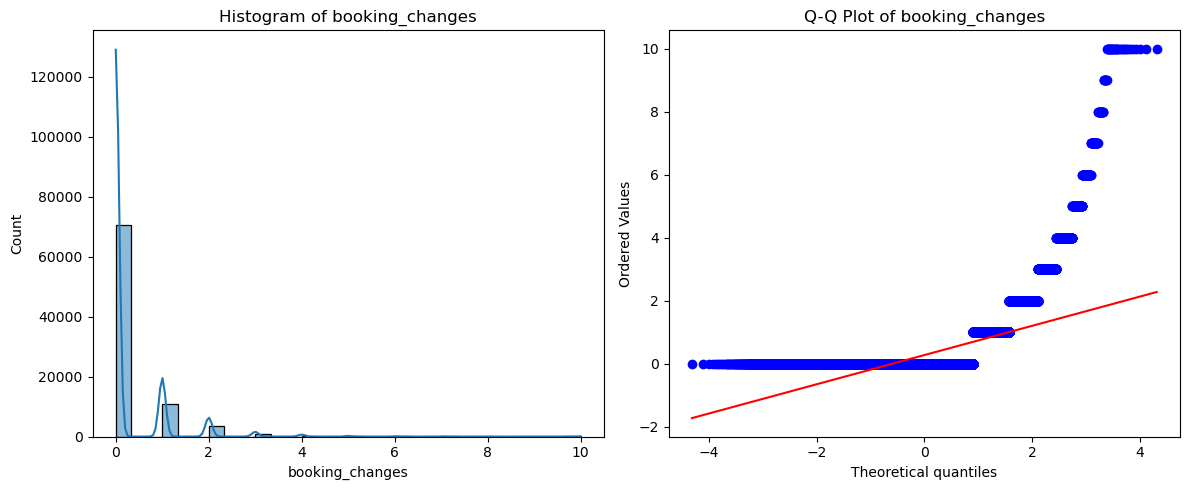

In [63]:
plot_hist_qq(df1,'booking_changes')

## 상관관계 분석

Text(0.5, 1.0, '예약 취소와의 상관관계')

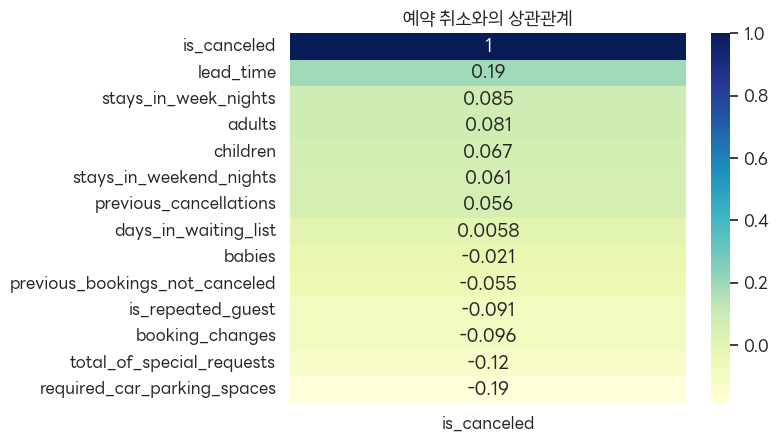

In [65]:
sns.set(font="LINE Seed Sans KR", rc={"axes.unicode_minus":False}, style='white',font_scale= 1.1)
sns.heatmap(df1.corr(numeric_only = True)[["is_canceled"]].sort_values(by="is_canceled", ascending=False), annot=True, cmap="YlGnBu")
plt.title("예약 취소와의 상관관계")

### Point-Biserial 상관계수

In [67]:
from scipy.stats import pointbiserialr

#### 'is_canceled'과 'lead_time'의 상관관계

/var/folders/g6/368p423d117c1pt_9pkjmw4w0000gn/T/ipykernel_87364/1607030781.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=pd.qcut(df1["lead_time"], q=5), y=df1["is_canceled"], ci=None)


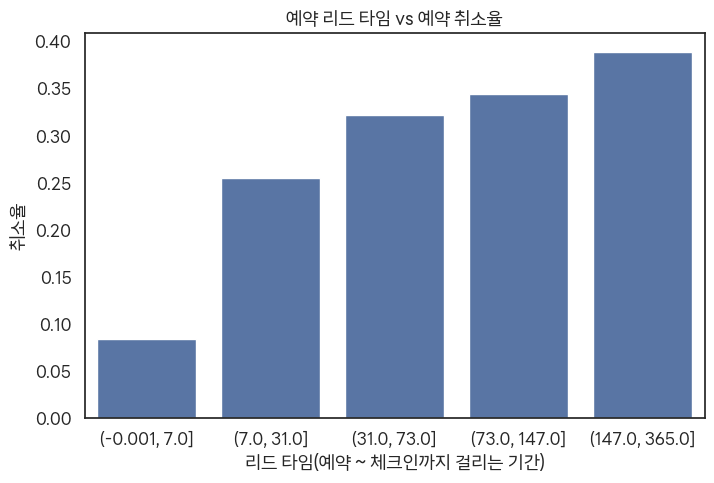

In [69]:
plt.figure(figsize=(8,5))
sns.barplot(x=pd.qcut(df1["lead_time"], q=5), y=df1["is_canceled"], ci=None)

plt.xlabel("리드 타임(예약 ~ 체크인까지 걸리는 기간)")
plt.ylabel("취소율")
plt.title("예약 리드 타임 vs 예약 취소율")
plt.show()

In [70]:
corr, p_value = pointbiserialr(df1['is_canceled'], df1['lead_time'])
print(f"Point-Biserial 상관계수: {corr}, p-value: {p_value}")

Point-Biserial 상관계수: 0.19268041669248814, p-value: 0.0


- lead_time 길수록 취소율이 높다
  : 미리 예약한 고객이 취소할 가능성이 높다
  : 오래된 계획일수록 일정이 변할 가능성이 높다
- lead_time이 짧을수록 취소율이 낮음
  : 체크인 날짜가 가까워질수록 예약을 더 확실하게 유지하는 경향이 있다

(개선책)
1. 미리 예약한 고객을 대상으로 리마인드 메세지나 할인 정책을 제공
2. 예약가능한 기간을 체크인 날짜로 부터 3개월 이내로 줄이기
3. 가까운 일정의 예약을 유도하는 프로모션 전략 고려

#### "stays_in_weekend_nights + stays_in_week_nights"와 "is_canceled"의 상관관계

In [73]:
corr, p_value = pointbiserialr(df1['is_canceled'], df1['stays_in_weekend_nights']+ df1['stays_in_week_nights'])
print(f"Point-Biserial 상관계수: {corr}, p-value: {p_value}")

Point-Biserial 상관계수: 0.08582230301329889, p-value: 1.2257586032656808e-140


- 숙박 일수와 예약 취소율 간의 상관관계는 미미하다

#### "previous_cancellations"와 "is_canceled"의 상관관계

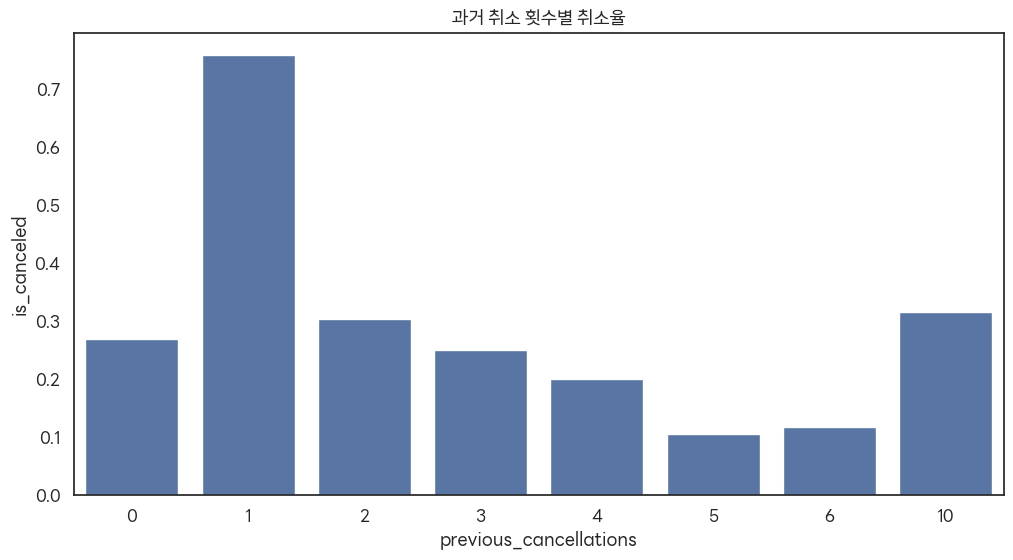

In [76]:
plt.figure(figsize=(12,6))
sns.barplot(x=df1["previous_cancellations"], y=df1["is_canceled"], estimator=lambda x: sum(x)/len(x),errorbar=None)
plt.title("과거 취소 횟수별 취소율")
plt.show()

In [77]:
corr, p_value = pointbiserialr(df1['is_canceled'], df1['previous_cancellations'])
print(f"Point-Biserial 상관계수: {corr}, p-value: {p_value}")

Point-Biserial 상관계수: 0.05597491972801344, p-value: 8.527107332830398e-61


- 상관계수가 0.05인 매우 약한 상관관계이므로 이전에 예약을 취소한 경험이 있다고 해서 반드시 취소하는 것이 아니다.
- 하지만 p-value로 이전에 취소한 횟수가 많을수록 다시 취소할 가능성이 조금 더 높다는 것을 알게 되었다.

==> 이 변수 하나만으로 취소 여부를 결정짓기는 어렵다

#### "booking_changes"와 "is_canceled"의 상관관계

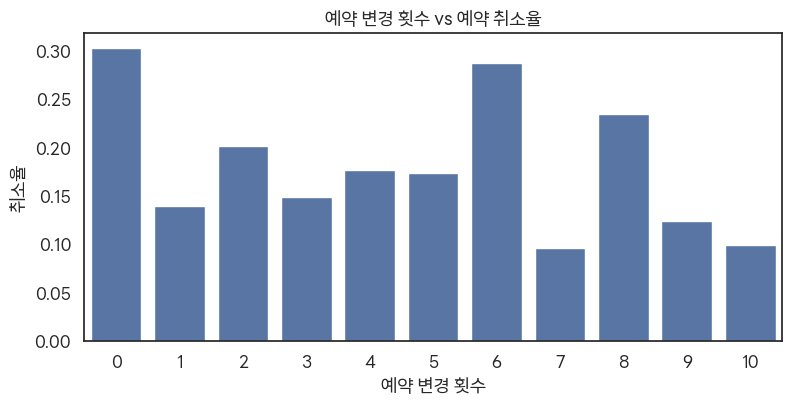

In [80]:
plt.figure(figsize=(9,4))
sns.barplot(x="booking_changes", y="is_canceled", data=df1, estimator=lambda x: sum(x)/len(x),errorbar=None)
plt.xlabel("예약 변경 횟수")
plt.ylabel("취소율")
plt.title("예약 변경 횟수 vs 예약 취소율")
plt.show()

In [81]:
corr, p_value = pointbiserialr(df1['is_canceled'], df1['booking_changes'])
print(f"Point-Biserial 상관계수: {corr}, p-value: {p_value}")

Point-Biserial 상관계수: -0.09604155832028904, p-value: 8.960572553108069e-176


(예상) 예약 변경이 많을수록 취소 확률이 높을 것

(실제) 상관관계가 음수(-0.09)이므로 오히려 예약변경이 많을수록 약간 감소한다.

#### "required_car_parking_spaces"와 "is_canceled"의 상관관계

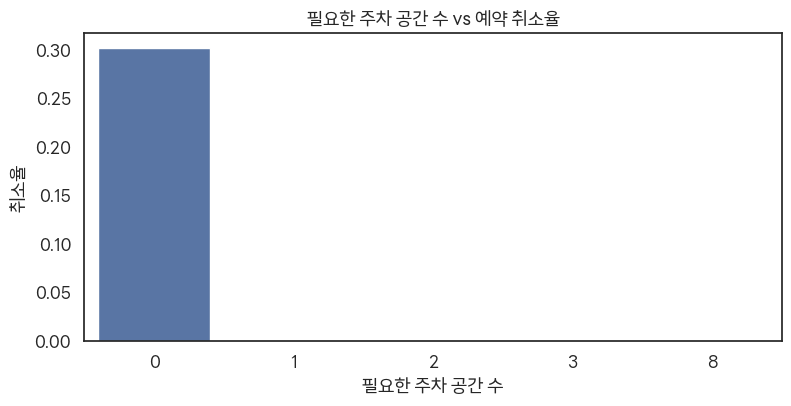

In [84]:
plt.figure(figsize=(9,4))
sns.barplot(x="required_car_parking_spaces", y="is_canceled", data=df1, estimator=lambda x: sum(x)/len(x),errorbar=None)
plt.xlabel("필요한 주차 공간 수")
plt.ylabel("취소율")
plt.title("필요한 주차 공간 수 vs 예약 취소율")
plt.show()

In [85]:
corr, p_value = pointbiserialr(df1['is_canceled'], df1['required_car_parking_spaces'])
print(f"Point-Biserial 상관계수: {corr}, p-value: {p_value}")

Point-Biserial 상관계수: -0.185872650712793, p-value: 0.0


- required_car_parking_spaces == 0
  : 취소율이 상대적으로 높다
- required_car_parking_spaces > 0
  : 최소율이 낮다

==> 주차공간을 요구하는 고객은 예약을 취소할 가능성이 낮다
==> 여행을 확정한 고객 또는 비즈니스 출장 혹은 장거리 여행객일 가능성이 있다.

#### "total_of_special_requests"와 "is_canceled"의 상관관계

/var/folders/g6/368p423d117c1pt_9pkjmw4w0000gn/T/ipykernel_87364/3626054175.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="total_of_special_requests", y="is_canceled", data=df1, ci=None)


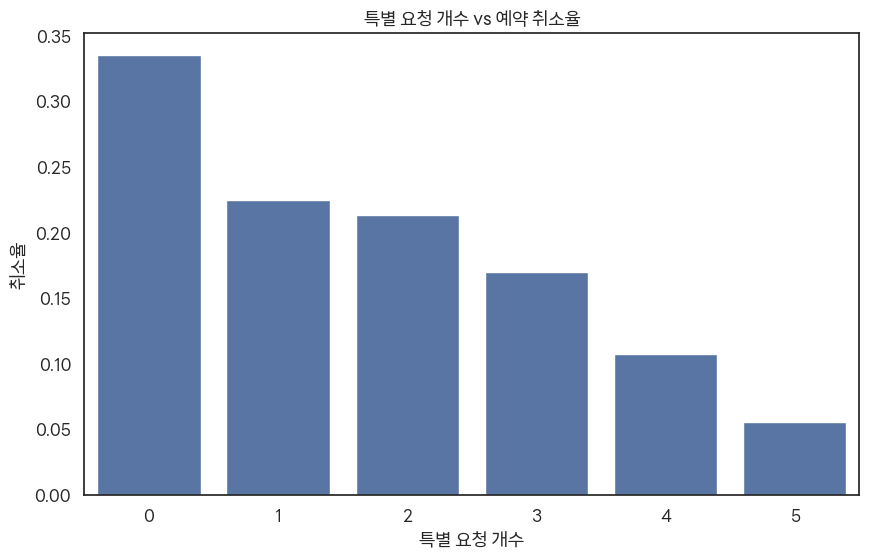

In [88]:
plt.figure(figsize=(10,6))
sns.barplot(x="total_of_special_requests", y="is_canceled", data=df1, ci=None)
plt.xlabel("특별 요청 개수")
plt.ylabel("취소율")
plt.title("특별 요청 개수 vs 예약 취소율")
plt.show()

In [89]:
corr, p_value = pointbiserialr(df1['is_canceled'], df1['total_of_special_requests'])
print(f"Point-Biserial 상관계수: {corr}, p-value: {p_value}")

Point-Biserial 상관계수: -0.12290539988122104, p-value: 2.3276087340261786e-287


-> total_of_special_requests == 0
  : 취소율이 상대적으로 높다
  
-> total_of_special_requests > 0
  : 최소율이 상대적으로 낮다

- 특별 요청이 많은 고객은 예약을 취소할 가능성이 낮다
- 요청이 많은 경우 = 호텔에 대한 기대치가 높음 / 여행계획 확실하여 취소율이 낮다.
- 요청이 없는 단순 고객일수록 쉽게 취소하는 경향이 있다.

### 이외의 상관관계

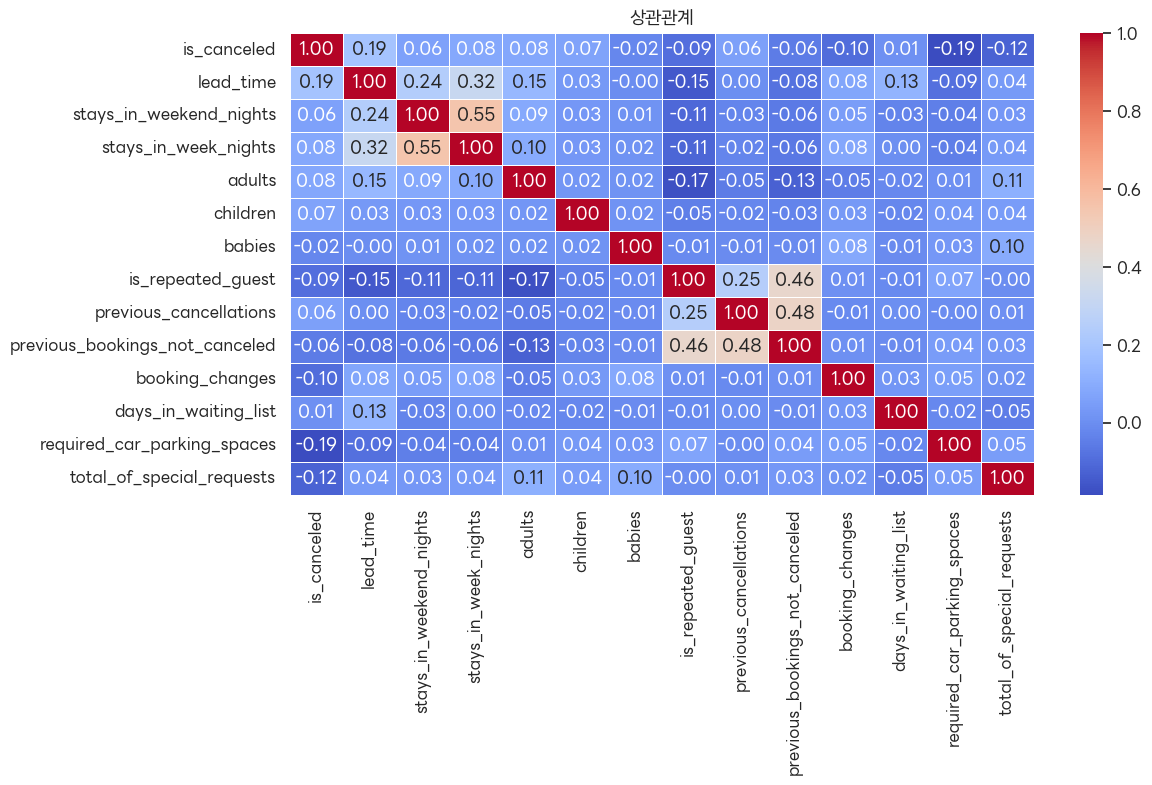

In [92]:
# 히트맵 시각화
sns.set(font="LINE Seed Sans KR", rc={"axes.unicode_minus":False}, style='white',font_scale= 1.1)
plt.figure(figsize=(12, 6))
sns.heatmap(df1.corr(numeric_only = True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("상관관계")
plt.show()

1. stays_in_week_nights(주중 숙박일) - stays_in_weekend_nights(주말 숙박일): 0.55
    : 전체 숙박 기간이 길수록 주말과 주중 숙박일 수도 함께 증가하는 경향이 있다.
2. previous_cancellations(이전 취소 횟수) - previous_bookings_not_canceled(이전에 취소 안한 예약 횟수)
    : 과거에 예약 취소를 많이 한 사람은 비취소 예약도 많이 보유한 경향이 있다.
3. previous_bookings_not_canceled(이전에 취소 안한 예약 횟수) - is_repeated_guest(반복 방문 고객): 0.46
    : 반복 방문 고객일수록 이전에 취소 안한 예약을 많이 보유한 경향이 있다.
4. is_repeated_guest(반복 방문 고객) - previous_cancellations(이전 취소 횟수) : 0.25
    : 반복 방문 고객도 과거에 예약을 취소한 경험이 있을 가능성이 있음.
5. adults, children, babies(투숙 인원) -> is_canceled과 상관관계가 거의 없음.